In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

In [9]:
file_path = "../data/raw/Dados climáticos de 1984 a 2014 - Formatado.xlsx"

In [10]:
dados = pd.read_excel(file_path, sheet_name="dados")

In [11]:
dados.columns = dados.columns.str.strip()

In [12]:
dados.columns.tolist()

['Data',
 'mm/dia - Precipitação',
 'mm/dia - Evapotranspiração',
 'C° - Temperatura Média',
 'W/m² - Radiação']

In [13]:
df_indices = dados[[
"W/m² - Radiação",
"C° - Temperatura Média",
"mm/dia - Precipitação"
]].copy()

In [14]:
df_indices.head()

,W/m² - Radiação,C° - Temperatura Média,mm/dia - Precipitação
0,211.801254,25.419519,0.989776
1,204.752853,26.399133,0.166336
2,217.430527,26.202539,0.256648
3,222.075912,26.720331,0.000000
4,220.100525,27.286249,0.000000


In [15]:
df_norm = (df_indices - df_indices.min()) / (df_indices.max() - df_indices.min())

In [16]:
df_norm.head()

,W/m² - Radiação,C° - Temperatura Média,mm/dia - Precipitação
0,0.701174,0.538083,0.018626
1,0.655148,0.676959,0.003130
2,0.737933,0.649089,0.004830
3,0.768267,0.722494,0.000000
4,0.755368,0.802722,0.000000


In [17]:
df_indices["IPS"] = df_norm["W/m² - Radiação"]

In [18]:
df_indices["IECS"] = (
    df_norm["W/m² - Radiação"] +
    df_norm["C° - Temperatura Média"] -
    df_norm["mm/dia - Precipitação"]
)

In [19]:
df_indices[["IPS", "IECS"]].head()

,IPS,IECS
0,0.701174,1.220631
1,0.655148,1.328977
2,0.737933,1.382192
3,0.768267,1.490761
4,0.755368,1.558090


In [20]:
df_indices[["IPS", "IECS"]].describe()

,IPS,IECS
count,11322.000000,11322.000000
mean,0.529163,0.979109
std,0.173776,0.364740
min,0.000000,-0.539176
25%,0.397430,0.701562
50%,0.538515,1.015948
75%,0.663119,1.272415
max,1.000000,1.966594


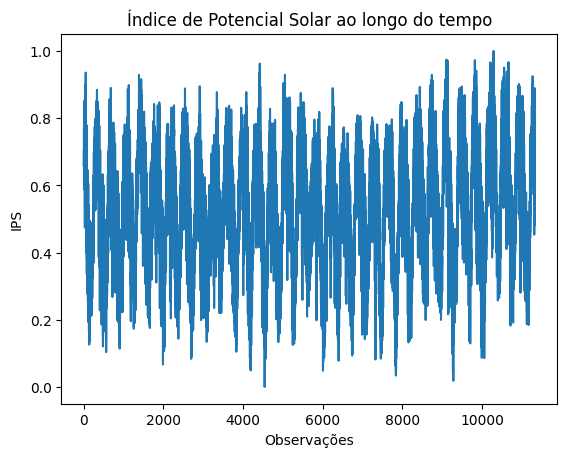

In [21]:
plt.plot(df_indices["IPS"])

plt.title("Índice de Potencial Solar ao longo do tempo")
plt.xlabel("Observações")
plt.ylabel("IPS")

plt.show()

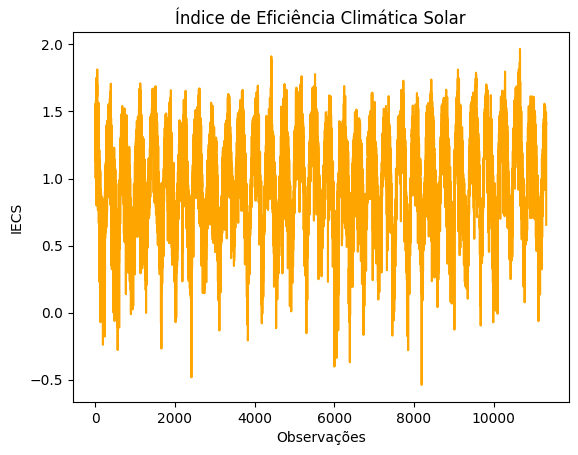

In [22]:
plt.plot(df_indices["IECS"], color="orange")

plt.title("Índice de Eficiência Climática Solar")
plt.xlabel("Observações")
plt.ylabel("IECS")

plt.show()

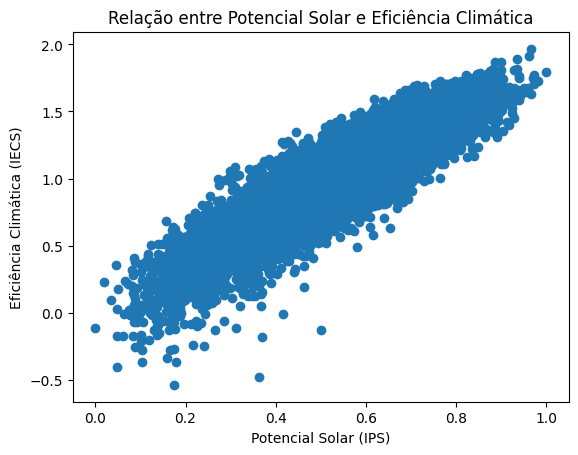

In [23]:
plt.scatter(df_indices["IPS"], df_indices["IECS"])

plt.xlabel("Potencial Solar (IPS)")
plt.ylabel("Eficiência Climática (IECS)")

plt.title("Relação entre Potencial Solar e Eficiência Climática")

plt.show()

# Relatório — Etapa 6: Índices Climáticos para Energia Solar

## 1. Objetivo

A etapa 6 teve como objetivo desenvolver **indicadores climáticos capazes de representar a qualidade das condições meteorológicas para geração de energia solar** ao longo do período analisado.

Para isso, foram construídos dois índices principais:

- **Índice de Potencial Solar (IPS)**
- **Índice de Eficiência Climática Solar (IECS)**

Esses índices permitem sintetizar múltiplas variáveis climáticas em métricas que facilitam a análise do potencial de geração solar da região.

---

# 2. Construção dos índices climáticos

## 2.1 Normalização das variáveis

Como as variáveis climáticas apresentam unidades e escalas diferentes, foi realizada uma **normalização Min-Max**, transformando os valores para uma escala entre **0 e 1**.

A normalização foi calculada pela fórmula:

Variável_normalizada = (X − Xmin) / (Xmax − Xmin)

Esse procedimento permite comparar e combinar variáveis climáticas distintas sem distorções causadas por diferenças de escala.

---

# 2.2 Índice de Potencial Solar (IPS)

O **Índice de Potencial Solar (IPS)** foi definido a partir da variável de **radiação solar normalizada**, pois a radiação é o principal fator que determina a geração de energia fotovoltaica.

Assim:

IPS = Radiação_normalizada

Valores mais próximos de **1** indicam **condições climáticas mais favoráveis à geração de energia solar**, enquanto valores próximos de **0** indicam menor potencial de geração.

---

# 2.3 Índice de Eficiência Climática Solar (IECS)

O **Índice de Eficiência Climática Solar (IECS)** foi construído combinando três variáveis climáticas relevantes:

- Radiação solar (efeito positivo)
- Temperatura média (efeito positivo)
- Precipitação (efeito negativo)

A formulação utilizada foi:

IECS = Radiação_normalizada + Temperatura_normalizada − Precipitação_normalizada

Esse índice busca representar **a eficiência climática do ambiente para geração solar**, considerando que:

- maior radiação aumenta o potencial de geração
- temperaturas mais elevadas geralmente estão associadas a maior incidência solar
- precipitação elevada tende a reduzir a disponibilidade de radiação devido à maior cobertura de nuvens

---

# 3. Estatísticas dos índices

A análise estatística dos índices gerados apresentou os seguintes resultados:

### Índice de Potencial Solar (IPS)

| Estatística | Valor |
|---|---|
Média | 0.529 |
Desvio padrão | 0.174 |
Mínimo | 0.000 |
Máximo | 1.000 |

Esses resultados indicam que o potencial solar apresenta **variabilidade moderada ao longo da série temporal**, com valores distribuídos ao redor de aproximadamente **0.53**, sugerindo um potencial solar médio relativamente estável.

---

### Índice de Eficiência Climática Solar (IECS)

| Estatística | Valor |
|---|---|
Média | 0.979 |
Desvio padrão | 0.365 |
Mínimo | -0.539 |
Máximo | 1.967 |

O índice IECS apresenta maior amplitude de variação, pois incorpora múltiplos fatores climáticos simultaneamente. Valores mais elevados indicam condições climáticas mais favoráveis para geração solar, enquanto valores negativos refletem períodos em que precipitação elevada ou condições climáticas desfavoráveis reduzem a eficiência climática.

---

# 4. Análise temporal dos índices

A análise gráfica do **Índice de Potencial Solar (IPS)** ao longo das observações mostra um comportamento cíclico consistente, indicando a presença de **variabilidade climática associada a padrões sazonais**.

Os picos do índice correspondem a períodos de maior incidência de radiação solar, enquanto os vales indicam períodos com menor disponibilidade de radiação.

O **Índice de Eficiência Climática Solar (IECS)** apresenta comportamento semelhante, porém com maior amplitude de variação devido à inclusão das variáveis de temperatura e precipitação no cálculo do índice.

---

# 5. Relação entre os índices

A análise da relação entre o **IPS** e o **IECS**, representada pelo gráfico de dispersão, indica uma **relação positiva clara entre os dois índices**.

Isso significa que:

- regiões ou períodos com **maior potencial solar (IPS)** tendem também a apresentar **maior eficiência climática para geração solar (IECS)**.

Essa relação é esperada, pois a radiação solar é um componente fundamental em ambos os índices.

---

# 6. Conclusão

Os índices climáticos desenvolvidos nesta etapa permitiram sintetizar as condições climáticas relevantes para a geração de energia solar em indicadores simples e interpretáveis.

O **Índice de Potencial Solar (IPS)** representa diretamente a disponibilidade de radiação solar, enquanto o **Índice de Eficiência Climática Solar (IECS)** incorpora múltiplos fatores climáticos que influenciam a eficiência da geração fotovoltaica.

Os resultados obtidos indicam que a região analisada apresenta **variabilidade climática moderada no potencial solar**, com forte relação entre o potencial solar e a eficiência climática.

Dessa forma, os índices desenvolvidos constituem ferramentas úteis para análises climáticas voltadas ao planejamento e avaliação do potencial de geração de energia solar.